# Triage Automatico

## Proyecto de inteligencia artificial
### Alejandro Roa
### Alisson Navarro
### Laura Holguin


En este cuaderno se entrenan diferentes modelos para escoger cual es el mejor clasificador para un triaje. El triaje (también escrito triage) es un método de selección y clasificación de pacientes utilizado en la enfermería y la medicina de emergencias y desastres, cuyo objetivo es evaluar las prioridades de atención según la gravedad de la condición clínica y los recursos disponibles.  

Entrenaremos **** y eligiremos el mejor modelo priorizando la metrica de la precision ya que nos importa mas que alguien que necesita atención urgente la reciba.


In [413]:
#Importamos las librerias necesarias para nuestro proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow import keras
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers

Para este proyecto utilizaremos una base de datos de Kaggle


Link dataset : https://www.kaggle.com/datasets/ilkeryildiz/emergency-service-triage-application


A continuación información sobre la base de datos que encontramos en el link del data set, tambien nos damos cuenta que poseemos una gran cantidad de variables que aunque se represntan numericamente realmente son variables categoricas

## Acerca del conjunto de datos

**Contexto**

Este estudio retrospectivo transversal se basó en 1267 registros seleccionados sistemáticamente de pacientes adultos admitidos en dos departamentos de urgencias entre octubre de 2016 y septiembre de 2017. Se evaluaron 24 variables, incluyendo los motivos principales de consulta, signos vitales según los registros iniciales de enfermería y los resultados clínicos.

Tres expertos en triage —una enfermera certificada en emergencias, un proveedor e instructor de KTAS y una enfermera recomendada por su excelente experiencia y competencia en el servicio de urgencias— determinaron el verdadero nivel KTAS.

**Contenido**

Variables:
* Sex: Sexo del paciente
* Age: Edad del paciente
* Arrival mode: Tipo de transporte utilizado para llegar al hospital
* Injury: Indica si el paciente presenta una lesión o no
* Chief_complain: Motivo principal de consulta del paciente
* Mental: Estado mental del paciente
* Pain: Indica si el paciente presenta dolor
* NRS_pain: Evaluación del dolor realizada por enfermería
* SBP: Presión arterial sistólica
* DBP: Presión arterial diastólica
* HR: Frecuencia cardíaca
* RR: Frecuencia respiratoria
* BT: Temperatura corporal

El documento técnico del proyecto del conjunto de datos fue consultado. En este documento se observó que algunos datos numéricos eran en realidad variables categóricas. Los valores son los siguientes:

* Reason Visit / Injury:
1 = No
2 = Sí
* Gender / Sex:
1 = Femenino
2 = Masculino
* Pain:
1 = Sí
0 = No
* Mental:
1 = Alerta
2 = Respuesta verbal
3 = Respuesta al dolor
4 = Sin respuesta
* Type of ED / Group:
1 = Servicio de urgencias local de tercer nivel
2 = Servicio de urgencias regional de cuarto nivel
* Mode of Arrival / Arrival Mode:
1 = Caminando
2 = Ambulancia pública
3 = Vehículo privado
4 = Ambulancia privada
5, 6, 7 = Otros
* Disposition:
1 = Alta médica
2 = Hospitalización en sala general
3 = Ingreso a UCI
4 = Alta médica
5 = Traslado
6 = Fallecimiento
7 = Cirugía
* KTAS:
1, 2, 3 = Emergencia
4, 5 = No emergencia

## Ahora pasaremos a cargar y limpiar el dataset

In [414]:
#Cargamos y visualizamos el dataset
df = pd.read_csv("/content/data.csv",sep=';',encoding="latin1", header = 0)
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


In [415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 14  BT                      

In [416]:
df.describe()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,Pain,KTAS_RN,Disposition,KTAS_expert,Error_group,Length of stay_min,mistriage
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.456985,1.521705,54.423836,7.519337,2.820837,1.192581,1.105762,0.563536,3.335438,1.609313,3.265983,0.558011,11016.102605,0.250197
std,0.498343,0.499726,19.725033,3.160563,0.807904,0.394482,0.447768,0.496143,0.885391,1.157983,0.885803,1.571489,80446.092065,0.628250
min,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,37.000000,5.000000,2.000000,1.000000,1.000000,0.000000,3.000000,1.000000,3.000000,0.000000,133.000000,0.000000
50%,1.000000,2.000000,57.000000,7.000000,3.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,0.000000,274.000000,0.000000
75%,2.000000,2.000000,71.000000,10.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,4.000000,0.000000,606.500000,0.000000
max,2.000000,2.000000,96.000000,17.000000,7.000000,2.000000,4.000000,1.000000,5.000000,7.000000,5.000000,9.000000,709510.000000,2.000000


## Verificamos si hay nulos y procedemos a tratarlos para limpiar el data set

In [417]:
df.isnull().sum()

,0
Group,0
Sex,0
Age,0
Patients number per hour,0
Arrival mode,0
Injury,0
Chief_complain,0
Mental,0
Pain,0
NRS_pain,0


In [418]:
df.isnull().sum().sum()

np.int64(690)

In [419]:
# Eliminamos filas con nulos en esa columna, ya que solo son 2
df = df.dropna(subset=["Diagnosis in ED"])

In [420]:
# Verificamos
df["Diagnosis in ED"].isnull().sum()

np.int64(0)

Tenemos 688 datos nulos en el data set sobre la saturación, no podemos eliminar estas filas porque son el 50% del data set, investigando un poco mas sobre el tema hay una gran posibilidad de que el dato de la saturación no exista, porque no se tomo debido a las condiciones del paciente, lo que tambien es un idicador, asi que crearemos una bandera para indicar que no se tomo sarturación y rellenamos los nulos con la mediana

In [421]:
# 1. Crear bandera de dato faltante
df["Saturation_missing"] = df["Saturation"].isnull().astype(int)

# 2. Convertir Saturation a numérica
df["Saturation"] = pd.to_numeric(df["Saturation"], errors="coerce")

# 3. Rellenar nulos con la mediana
df["Saturation"] = df["Saturation"].fillna(df["Saturation"].median())

# 4. Verificar
df["Saturation"].isnull().sum(), df["Saturation"].dtype

(np.int64(0), dtype('float64'))

In [422]:
#Verificamos que no nos queden nulos
df.isnull().sum().sum()

np.int64(0)

## Ahora trataremos los nulos del dataset que no son explicitamente nulos

In [423]:
# Exploramos el dataset columna por columna y agrupamos para visualizar
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].astype(str).value_counts().head(20))


===== Group =====
Group
1    688
2    577
Name: count, dtype: int64

===== Sex =====
Sex
2    659
1    606
Name: count, dtype: int64

===== Age =====
Age
58    36
74    29
68    28
77    28
56    27
75    27
27    25
69    25
79    25
22    25
59    24
72    24
57    24
65    24
53    24
78    24
81    23
60    23
67    22
29    21
Name: count, dtype: int64

===== Patients number per hour =====
Patients number per hour
5     160
8     145
6     143
9     137
7     136
10    113
4      85
12     84
3      82
11     56
13     34
2      31
15     22
1      16
14     13
17      8
Name: count, dtype: int64

===== Arrival mode =====
Arrival mode
3    751
2    266
4    155
1     79
6     10
5      2
7      2
Name: count, dtype: int64

===== Injury =====
Injury
1    1022
2     243
Name: count, dtype: int64

===== Chief_complain =====
Chief_complain
abd pain            72
dyspnea             59
dizziness           59
fever               45
ant. chest pain     44
Open Wound          31
headache

Aqui hacemos un acote importante que nos servira para despues: al agrupar y visualizar notamos que en la columna de Diagnosis in ED y Chief complain hay cosas que son lo mismo pero escrito de manera diferente, lo agruparemos posteriormente.

In [424]:
# Identificamos caracteres raros o nulos no explícitos y contamos cada valor

for col in df.columns:
    mask = df[col].astype(str).str.contains(r"#|Þ|\?|!", regex=True, na=False)

    if mask.sum() > 0:
        print(f"\n===== {col} =====")
        print("Total de valores raros:", mask.sum())
        print(df.loc[mask, col].value_counts())


===== Chief_complain =====
Total de valores raros: 22
Chief_complain
??            5
????          4
??? ??        3
?? ??         2
?? ???        2
???           2
?? ??? ??     1
??? ? ???     1
Pain, ?nus    1
??? ??? ??    1
Name: count, dtype: int64

===== NRS_pain =====
Total de valores raros: 555
NRS_pain
#BOÞ!    555
Name: count, dtype: int64

===== SBP =====
Total de valores raros: 25
SBP
??    25
Name: count, dtype: int64

===== DBP =====
Total de valores raros: 29
DBP
??    29
Name: count, dtype: int64

===== HR =====
Total de valores raros: 20
HR
??    20
Name: count, dtype: int64

===== RR =====
Total de valores raros: 22
RR
??    22
Name: count, dtype: int64

===== BT =====
Total de valores raros: 18
BT
??    18
Name: count, dtype: int64


Aqui analizaremos cada caso para definir que es lo mejor para cada uno

Empezaremos con el dolor reportado por la enferemera, nos damos cuenta que este es nulo cuando el paciente no reporta dolor o este es muy bajo, probablemente porque para la enfermela el valor fue 0 o no lo midio asi que lo remplazaremos por 0

In [425]:
# Reemplazar #BOÞ! por 0
df["NRS_pain"] = df["NRS_pain"].replace("#BOÞ!", 0)

# Convertir a numérico
df["NRS_pain"] = pd.to_numeric(df["NRS_pain"])

Ahora para los datos corruptos de chief_complain que es la razon por la cual llego a urgencias el paciente, los remplazaremos por desconocido ya que no sabemos la razon o pudo haber llegado en un estado en el que no la podia comunicar

In [426]:
df["Chief_complain"] = df["Chief_complain"].replace(
    [r".*\?.*"],
    "unknown",
    regex=True
)

Aprovechamos para normalizar los datos de esta columna

In [427]:
#convierte todo el texto a minúsculas y eliminamos espacios al inicio y al final
df["Chief_complain"] = (
    df["Chief_complain"]
    .str.lower()
    .str.strip()
)

# Unificar nombres que significan lo mismo
df["Chief_complain"] = df["Chief_complain"].replace({
    "abd. pain": "abdominal pain",
    "abd pain": "abdominal pain",
    "abdomen pain": "abdominal pain",
    "pain, chest": "chest pain",
    "left chest pain": "chest pain",
    "ant. chest pain": "chest pain"
})

Ahora para SBP, DBP, RR y BT ya que son signos vitales que no conocemos y no son muchos, los rellenaremos con la mediana

In [428]:
cols = ["SBP", "DBP", "HR", "RR", "BT"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [429]:
#Visualizamos como nos quedo nuestro data frame
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage,Saturation_missing
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,100.0,2,Corneal abrasion,1,4,2,86,"5,00",1,0
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,98.0,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1,1
2,2,1,68,8,2,2,"arm pain, lt",1,1,2,...,98.0,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1,0
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,98.0,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1,1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,98.0,4,Ascites,1,5,8,109,"6,60",1,1


##Ahora separamos nuestros datos de entrenamiento y de test
Para nuestro Y o etiqueta tomaremos el KTAS expert, eliminaremos el otro ktas para no tener un problema de data leak, porque ya que el objetivo es automatizar el triage en la inferencia no tendremos un ktas ya que es el objetivo

In [430]:
#Eliminamos el otro ktas, y el mistriage ya que es una metrica sobre el ktas rn
df = df.drop(columns=["KTAS_RN","mistriage","Disposition"])

In [431]:
#Separamos X y visualizamos
X = df.drop(columns=["KTAS_expert"])
X.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,DBP,HR,RR,BT,Saturation,Diagnosis in ED,Error_group,Length of stay_min,KTAS duration_min,Saturation_missing
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,100.0,84.0,18.0,36.6,100.0,Corneal abrasion,2,86,"5,00",0
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,75.0,60.0,20.0,36.5,98.0,"Burn of hand, firts degree dorsum",4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, lt",1,1,2,...,80.0,102.0,20.0,36.6,98.0,"Fracture of surgical neck of humerus, closed",4,862,"1,00",0
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,94.0,88.0,20.0,36.5,98.0,Alcoholic liver cirrhosis with ascites,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,67.0,93.0,18.0,36.5,98.0,Ascites,8,109,"6,60",1


In [432]:
#Separamos Y y visualizamos
Y = df[["KTAS_expert"]]
Y.head()

,KTAS_expert
0,4
1,5
2,5
3,5
4,5


In [433]:
# Ahora si separamos el conjunto de entrenamiento y prueba
X_train, X_test, y_train , y_test = train_test_split(X, Y, random_state=42, test_size= 0.2, stratify=Y)

## Ahora podemos proceder a codificar las variables categoricas

Segun nuestra base de datos tenemos que las variables categoricas son:
* Chief_complain: Motivo principal de consulta del paciente
* Diagnosisi in ED
* Reason Visit / Injury:
1 = No
2 = Sí
* Gender / Sex:
1 = Femenino
2 = Masculino
* Pain:
1 = Sí
0 = No
* Mental:
1 = Alerta
2 = Respuesta verbal
3 = Respuesta al dolor
4 = Sin respuesta
* Type of ED / Group:
1 = Servicio de urgencias local de tercer nivel
2 = Servicio de urgencias regional de cuarto nivel
* Mode of Arrival / Arrival Mode:
1 = Caminando
2 = Ambulancia pública
3 = Vehículo privado
4 = Ambulancia privada
5, 6, 7 = Otros
* Disposition:
1 = Alta médica
2 = Hospitalización en sala general
3 = Ingreso a UCI
4 = Alta médica
5 = Traslado
6 = Fallecimiento
7 = Cirugía
* KTAS:
1, 2, 3 = Emergencia
4, 5 = No emergencia


Usaremos una codificación one hot encoder para nuestras variables categoricas

In [434]:
#Separamos nuestro df de categoricas del X train
df_categoricas_train = X_train[["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Diagnosis in ED","Error_group","Saturation_missing"]]
df_categoricas_train.head()

,Group,Sex,Arrival mode,Injury,Chief_complain,Mental,Diagnosis in ED,Error_group,Saturation_missing
224,1,1,3,1,for a/tapping,1,Liver cirrhosis Child-Pugh A,0,1
740,1,2,3,1,lt flank pain,1,Ureter stone,0,1
1194,2,1,2,1,hematemesis,1,"Gastrointestinal haemorrhage, unspecified",0,0
951,1,1,3,1,dizziness,1,Benign paroxysmal positional vertigo,0,1
964,2,2,3,1,chest palpitation,1,Supraventricular tachycardia,0,0


In [435]:
#Ahora lo hacemos con X test
df_categoricas_test = X_test[["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Diagnosis in ED","Error_group","Saturation_missing"]]
df_categoricas_test.head()

,Group,Sex,Arrival mode,Injury,Chief_complain,Mental,Diagnosis in ED,Error_group,Saturation_missing
230,1,1,3,1,acute epigastric pain,1,Acute gastritis,0,1
874,1,2,3,2,finger laceration,1,Laceration of finger without nail damage,0,1
465,1,1,3,1,abdominal pain,1,"Pelvic inflammatory disease, female",0,1
790,1,2,2,1,post seizure,2,Seizure,0,1
873,1,1,3,1,facial palsy,1,Bell's palsy,0,1


###Ahora instanciamos nuestro codificador y codificamos nuestro df categorico

In [436]:
#Instanciamos el codificador
encoder = OneHotEncoder(handle_unknown="ignore")
#Codificamos
df_categoricas_train_1hot = encoder.fit_transform(df_categoricas_train)

(Oportunidad de mejora, TF-IDF en vez de one hot)

In [437]:
#Ahora con los datos de test
df_categoricas_test_1hot = encoder.transform(df_categoricas_test)

In [438]:
# creamos un nuevo dataFrame con las nuevas columnas
df_categoricas_train = pd.DataFrame(df_categoricas_train_1hot.toarray() ,
                         columns=encoder.get_feature_names_out())

In [439]:
df_categoricas_train.head()

,Group_1,Group_2,Sex_1,Sex_2,Arrival mode_1,Arrival mode_2,Arrival mode_3,Arrival mode_4,Arrival mode_5,Arrival mode_6,...,Error_group_2,Error_group_3,Error_group_4,Error_group_5,Error_group_6,Error_group_7,Error_group_8,Error_group_9,Saturation_missing_0,Saturation_missing_1
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [440]:
# ahora con los datos de test
df_categoricas_test = pd.DataFrame(df_categoricas_test_1hot.toarray() ,
                         columns=encoder.get_feature_names_out())

In [441]:
df_categoricas_test.head()

,Group_1,Group_2,Sex_1,Sex_2,Arrival mode_1,Arrival mode_2,Arrival mode_3,Arrival mode_4,Arrival mode_5,Arrival mode_6,...,Error_group_2,Error_group_3,Error_group_4,Error_group_5,Error_group_6,Error_group_7,Error_group_8,Error_group_9,Saturation_missing_0,Saturation_missing_1
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


##Ahora vamos estandarizar los datos

In [442]:
#primero borramos las columnas de nuestras variables categoricas
X_train = X_train.drop(columns=["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Diagnosis in ED","Error_group","Saturation_missing"])

In [443]:
#Ahora de nuestro X test
X_test = X_test.drop(columns=["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Diagnosis in ED","Error_group","Saturation_missing"])

In [444]:
# Convertir todo X_train y X_test a numérico
# Reemplaza comas decimales por puntos y convierte errores a NaN

X_train = X_train.astype(str).replace(",", ".", regex=True)
X_test = X_test.astype(str).replace(",", ".", regex=True)
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

In [445]:
#instanciamos nuestro scalador
st_x = StandardScaler()
X_train_std = st_x.fit_transform(X_train)
X_test_std = st_x.transform(X_test)

In [446]:
#Concatenamos nuestras categoricas
X_train_std = pd.concat([pd.DataFrame(X_train_std, columns=X_train.columns), df_categoricas_train], axis=1)
X_train_std

,Age,Patients number per hour,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,...,Error_group_2,Error_group_3,Error_group_4,Error_group_5,Error_group_6,Error_group_7,Error_group_8,Error_group_9,Saturation_missing_0,Saturation_missing_1
0,0.924739,-0.821715,0.875296,0.286350,-0.088289,-1.739274,-0.888048,-1.727604,1.558242,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.559415,0.136690,0.875296,2.003599,2.463471,1.686440,0.251146,-1.727604,-1.862866,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.538872,0.775626,-1.142471,-1.001587,0.614370,1.350586,0.970638,0.262533,0.037749,-0.476992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.303527,-0.821715,-1.142471,-1.001587,-1.160768,-2.343812,-1.487624,-0.732535,-0.532435,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.201171,-0.182779,-1.142471,-1.001587,-1.234732,-1.336249,1.570213,0.262533,-0.722497,-0.476992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,0.105895,-1.460652,0.875296,0.715662,1.095136,0.947561,-0.048641,-1.727604,0.797996,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1008,0.208251,0.136690,-1.142471,-1.001587,-0.125271,0.007168,-2.866648,0.262533,-0.722497,-0.166564,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1009,0.003540,-0.182779,0.875296,3.291536,0.688334,1.081902,-2.027242,-1.727604,0.227811,0.143865,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1010,1.027095,0.775626,0.875296,0.286350,-1.234732,-1.336249,-0.708175,-0.732535,0.037749,-0.166564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [447]:
#Ahora con el conjunto de test
X_test_std = pd.concat([pd.DataFrame(X_test_std, columns=X_test.columns), df_categoricas_test], axis=1)
X_test_std

,Age,Patients number per hour,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,...,Error_group_2,Error_group_3,Error_group_4,Error_group_5,Error_group_6,Error_group_7,Error_group_8,Error_group_9,Saturation_missing_0,Saturation_missing_1
0,-0.968837,0.456158,0.875296,0.286350,0.281531,0.208681,-1.547581,-1.727604,-0.722497,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.275904,0.136690,-1.142471,-1.001587,-0.162253,-0.261515,0.191189,-0.732535,0.417873,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.531792,1.414563,0.875296,0.715662,-0.569056,-1.067565,-0.768133,0.262533,0.227811,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.259429,-0.182779,-1.142471,-1.001587,1.797795,-0.395857,1.870001,-0.732535,-1.102620,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.327081,0.775626,-1.142471,-1.001587,0.022657,-0.261515,-0.948005,0.262533,0.797996,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,0.975917,-1.141184,0.875296,2.003599,0.059639,1.417757,1.150510,-0.732535,-0.722497,0.143865,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
249,-1.020015,-1.141184,-1.142471,-1.001587,0.836262,1.081902,2.349662,-0.732535,-0.152312,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
250,0.566495,-0.182779,-1.142471,-1.001587,0.355495,0.477365,2.829323,0.262533,-1.102620,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
251,-1.224726,0.775626,0.875296,0.286350,2.426489,2.156636,1.630171,0.262533,0.607934,0.143865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#Ahora entrenamos diferentes modelos

##Regresion logistica

In [448]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_std, y_train)
y_pred = logreg.predict(X_test_std)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [449]:
accuracy_score(y_test, y_pred)

0.6640316205533597

## SVM

Ahora buscaremos el mejor SVM

In [450]:
# Definir el modelo SVM
svm_clf = SVC(class_weight="balanced")

In [451]:
# Definir la cuadrícula de hiperparámetros
param_grid_svm = [
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 50, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1, 1]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10, 50],
        "gamma": ["scale", 0.001, 0.01, 0.1],
        "degree": [2, 3, 4],
        "coef0": [0, 0.5, 1]
    },
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10, 100]
    }
]

In [452]:
# Configurar el GridSearch con validación cruzada de 3 conjuntos
grid_search_svm = GridSearchCV(estimator=svm_clf,param_grid=param_grid_svm,scoring="f1_macro",cv=5)

In [453]:
# Entrenar con el conjunto de parámetros
grid_search_svm.fit(X_train_std, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'),
             param_grid=[{'C': [0.1, 1, 10, 50, 100],
                          'gamma': ['scale', 0.001, 0.01, 0.1, 1],
                          'kernel': ['rbf']},
                         {'C': [0.1, 1, 10, 50], 'coef0': [0, 0.5, 1],
                          'degree': [2, 3, 4],
                          'gamma': ['scale', 0.001, 0.01, 0.1],
                          'kernel': ['poly']},
                         {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear']}],
             scoring='f1_macro')

In [454]:
# Imprimir los mejores hiperparámetros
print("Mejores hiperparámetros para SVM:", grid_search_svm.best_params_)

Mejores hiperparámetros para SVM: {'C': 50, 'coef0': 1, 'degree': 2, 'gamma': 0.01, 'kernel': 'poly'}


In [455]:
# Predicciones
y_pred_svm_best = grid_search_svm.best_estimator_.predict(X_test_std)
y_pred_svm_best

array([4, 4, 3, 3, 3, 2, 4, 3, 4, 2, 2, 4, 3, 4, 3, 4, 3, 4, 4, 3, 3, 3,
       4, 4, 4, 3, 3, 4, 4, 3, 2, 4, 3, 4, 3, 1, 2, 4, 4, 2, 4, 3, 3, 2,
       4, 3, 3, 3, 3, 2, 3, 3, 4, 4, 2, 4, 3, 3, 4, 3, 2, 4, 2, 3, 3, 3,
       3, 4, 4, 4, 3, 4, 3, 3, 3, 3, 4, 4, 4, 2, 4, 5, 4, 2, 2, 2, 3, 2,
       4, 4, 4, 3, 3, 3, 2, 4, 3, 5, 4, 3, 4, 4, 4, 3, 4, 3, 2, 4, 2, 4,
       3, 2, 4, 3, 4, 2, 2, 3, 5, 3, 3, 2, 3, 3, 3, 4, 4, 3, 4, 3, 3, 3,
       2, 4, 4, 5, 2, 3, 4, 3, 3, 3, 2, 4, 4, 3, 4, 3, 2, 3, 3, 4, 4, 4,
       4, 3, 1, 3, 4, 2, 3, 4, 2, 3, 4, 3, 2, 3, 4, 4, 2, 4, 4, 2, 3, 3,
       2, 4, 4, 2, 2, 2, 4, 2, 4, 3, 3, 3, 2, 4, 2, 4, 3, 5, 2, 2, 3, 4,
       3, 2, 2, 3, 2, 3, 3, 3, 2, 4, 3, 3, 4, 4, 4, 3, 3, 4, 4, 4, 4, 4,
       4, 3, 4, 4, 3, 4, 4, 4, 5, 3, 3, 3, 4, 4, 3, 2, 2, 3, 2, 3, 2, 3,
       4, 3, 4, 4, 3, 4, 3, 3, 3, 4, 3])

In [456]:
accuracy = accuracy_score(y_test, y_pred_svm_best)
print(f"Precisión del modelo: {accuracy * 100:.2f}%")

Precisión del modelo: 69.17%


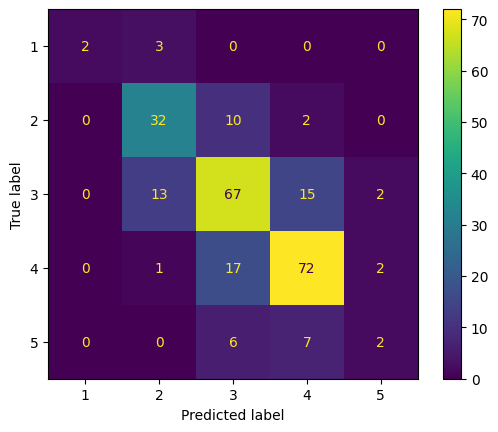

In [457]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_svm_best)

##Red Neuronal

In [458]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1. Preparar y
# =========================
# Aplanar y convertir KTAS de 1-5 a 0-4
y_train_rna = np.ravel(y_train).astype(int) - 1
y_test_rna = np.ravel(y_test).astype(int) - 1

print("Forma y_train:", y_train_rna.shape)
print("Clases y_train:", np.unique(y_train_rna))

# =========================
# 2. Pesos de clases
# =========================
classes = np.unique(y_train_rna)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_rna
)

class_weights = dict(zip(classes, weights))

print("Pesos:", class_weights)

# =========================
# 3. Crear RNA
# =========================
model = Sequential([
    Input(shape=(X_train_std.shape[1],)),

    Dense(64, activation="relu",kernel_regularizer=l2(0.01)),
    Dropout(0.3),

    Dense(32, activation="relu",kernel_regularizer=l2(0.01)),
    Dropout(0.2),

    Dense(5, activation="softmax")
])

# =========================
# 4. Compilar
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 5. Early stopping
# =========================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

# =========================
# 6. Entrenar
# =========================
history = model.fit(
    X_train_std,
    y_train_rna,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 7. Evaluar
# =========================
y_pred_probs = model.predict(X_test_std)
y_pred_rna = np.argmax(y_pred_probs, axis=1)

# Volver de 0-4 a 1-5
y_pred_rna_original = y_pred_rna + 1

print("\nAccuracy RNA:")
print(accuracy_score(y_test, y_pred_rna_original))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rna_original))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rna_original))

Forma y_train: (1012,)
Clases y_train: [0 1 2 3 4]
Pesos: {np.int64(0): np.float64(9.638095238095238), np.int64(1): np.float64(1.1565714285714286), np.int64(2): np.float64(0.518974358974359), np.int64(3): np.float64(0.5530054644808743), np.int64(4): np.float64(3.3733333333333335)}
Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2077 - loss: 2.7630 - val_accuracy: 0.3498 - val_loss: 2.3457
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3041 - loss: 2.1734 - val_accuracy: 0.3842 - val_loss: 1.9513
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3090 - loss: 1.8922 - val_accuracy: 0.3941 - val_loss: 1.8039
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3412 - loss: 1.7150 - val_accuracy: 0.4039 - val_loss: 1.6907
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3646 - loss: 1.6165 - val_accuracy: 0.3941 - val_loss: 1.6437
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3585 - loss: 1.53

##Probando los modelos de chatcito

In [459]:
# =========================
# Instalar librerías
# =========================
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.9 MB/s eta 0:00:00


In [460]:
# =========================
# Imports
# =========================
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [464]:
# =========================
# Preparar y para modelos
# =========================

# Para sklearn, LightGBM y CatBoost puedes usar y normal 1-5
y_train_normal = np.ravel(y_train).astype(int)
y_test_normal = np.ravel(y_test).astype(int)

# Para XGBoost es mejor pasar de 1-5 a 0-4
y_train_xgb = y_train_normal - 1
y_test_xgb = y_test_normal - 1

In [465]:
# =========================
# Modelos
# =========================

modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=5,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0
    )
}

In [466]:
# =========================
# Entrenar y evaluar
# =========================

resultados = []

for nombre, modelo in modelos.items():

    print(f"\n==================== {nombre} ====================")

    if nombre == "XGBoost":
        modelo.fit(X_train_std, y_train_xgb)
        y_pred = modelo.predict(X_test_std) + 1
    else:
        modelo.fit(X_train_std, y_train_normal)
        y_pred = modelo.predict(X_test_std)

    acc = accuracy_score(y_test_normal, y_pred)
    f1_macro = f1_score(y_test_normal, y_pred, average="macro")

    resultados.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "F1_macro": f1_macro
    })

    print(f"Accuracy: {acc*100:.2f}%")
    print(f"F1 macro: {f1_macro:.4f}")
    print("\nReporte:")
    print(classification_report(y_test_normal, y_pred))
    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test_normal, y_pred))


==================== Random Forest ====================
Accuracy: 67.59%
F1 macro: 0.5137

Reporte:
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.73      0.43      0.54        44
           3       0.61      0.81      0.70        97
           4       0.74      0.77      0.76        92
           5       0.00      0.00      0.00        15

    accuracy                           0.68       253
   macro avg       0.62      0.48      0.51       253
weighted avg       0.65      0.68      0.65       253


Matriz de confusión:
[[ 2  3  0  0  0]
 [ 0 19 23  2  0]
 [ 0  3 79 15  0]
 [ 0  1 20 71  0]
 [ 0  0  7  8  0]]

==================== XGBoost ====================


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 67.59%
F1 macro: 0.5800

Reporte:
              precision    recall  f1-score   support

           1       0.75      0.60      0.67         5
           2       0.64      0.52      0.57        44
           3       0.65      0.73      0.69        97
           4       0.72      0.78      0.75        92
           5       0.67      0.13      0.22        15

    accuracy                           0.68       253
   macro avg       0.68      0.55      0.58       253
weighted avg       0.67      0.68      0.66       253


Matriz de confusión:
[[ 3  2  0  0  0]
 [ 1 23 17  3  0]
 [ 0  9 71 17  0]
 [ 0  1 18 72  1]
 [ 0  1  4  8  2]]

==================== LightGBM ====================


LightGBMError: Do not support special JSON characters in feature name.

In [ ]:
# =========================
# Comparación final
# =========================

resultados_df = pd.DataFrame(resultados).sort_values(
    by="F1_macro",
    ascending=False
)

resultados_df